In [1]:
import polars as pl
import re

VALID_LABELS = {
    "API ключи",
    "CVV/CVC",
    "Email",
    "Водительское удостоверение",
    "Временное удостоверение личности",
    "Гражданство и названия стран",
    "Данные об автомобиле клиента",
    "Данные об организации/юридическом лице (ИНН, КПП, ОГРН, БИК, адреса, расчётный счёт)",
    "Дата окончания срока действия карты",
    "Дата регистрации по месту жительства или пребывания",
    "Дата рождения",
    "Имя держателя карты",
    "Кодовые слова",
    "Место рождения",
    "Наименование банка",
    "Номер банковского счета",
    "Номер карты",
    "Номер телефона",
    "Одноразовые коды",
    "ПИН код",
    "Пароли",
    "Паспортные данные",
    "Полный адрес",
    "Разрешение на работу / визу",
    "СНИЛС клиента",
    "Сведения об ИНН",
    "Свидетельство о рождении",
    "Серия и номер вида на жительство",
    "Содержимое магнитной полосы",
    "ФИО",
}
data_synth = pl.read_csv(
    "/kaggle/input/datasets/maksonchek/synt-ner/handwritten_ner_examples_text_target.csv"
)

def extract_labels(target: str):
    if target == "[]":
        return []
    return re.findall(r"'([^']+)'", target)

synth_with_labels = data_synth.with_columns(
    pl.col("target").map_elements(extract_labels, return_dtype=pl.List(pl.Utf8)).alias("labels")
)

bad_rows = (
    synth_with_labels
    .with_columns(
        pl.col("labels").map_elements(
            lambda xs: [x for x in xs if x not in VALID_LABELS],
            return_dtype=pl.List(pl.Utf8)
        ).alias("bad_labels")
    )
    .filter(pl.col("bad_labels").list.len() > 0)
)

print("Число строк с битыми метками:", bad_rows.shape[0])
display(bad_rows.select(["text", "target", "bad_labels"]))

REPLACE_BAD_LABELS = {
    "гражданство» у клиента указана страна «Гражданство и названия стран": "Гражданство и названия стран",
    "дата рождения» сейчас указано значение «Дата рождения": "Дата рождения",
}
tuple_pattern = re.compile(r"\((\d+),\s*(\d+),\s*'([^']+)'\)")

def clean_target(target: str) -> str:
    if target == "[]":
        return target

    tuples = tuple_pattern.findall(target)
    cleaned = []

    for s, e, label in tuples:
        label = REPLACE_BAD_LABELS.get(label, label)
        cleaned.append(f"({int(s)}, {int(e)}, '{label}')")

    return "[" + ", ".join(cleaned) + "]" if cleaned else "[]"

data_synth_clean = data_synth.with_columns(
    pl.col("target").map_elements(clean_target, return_dtype=pl.Utf8).alias("target")
)

def get_unique_labels(df):
    return (
        df
        .filter(pl.col("target") != "[]")
        .select(
            pl.col("target")
            .str.extract_all(r"'([^']+)'")
            .explode()
            .alias("label")
        )
        .filter(pl.col("label").is_not_null())
        .unique()
        .sort("label")
    )

unique_labels_synth_clean = get_unique_labels(data_synth_clean)
print("Количество уникальных классов после чистки:", unique_labels_synth_clean.shape[0])
display(unique_labels_synth_clean)

data = pl.read_csv(
    "/kaggle/input/competitions/llm-march2026-alfabank/train_dataset.tsv",
    separator="\t"
)

orig_labels = set(get_unique_labels(data)["label"].to_list())
synth_labels = set(get_unique_labels(data_synth_clean)["label"].to_list())

print("Совпадают ли множества классов?", orig_labels == synth_labels)

print("\nНет в synthetic:")
print(sorted(orig_labels - synth_labels))

print("\nЛишние в synthetic:")
print(sorted(synth_labels - orig_labels))

data_all = pl.concat(
    [
        data.select(["text", "target"]),
        data_synth_clean.select(["text", "target"]),
    ],
    how="vertical"
)

print(data.shape)
print(data_synth_clean.shape)
print(data_all.shape)

# data = data_all

Число строк с битыми метками: 18


text,target,bad_labels
str,str,list[str]
"""В графе Россия.""","""[(8, 14, 'гражданство» у клиен…","[""гражданство» у клиента указана страна «Гражданство и названия стран""]"
"""В графе Израиль.""","""[(8, 15, 'гражданство» у клиен…","[""гражданство» у клиента указана страна «Гражданство и названия стран""]"
"""В графе Армения.""","""[(8, 15, 'гражданство» у клиен…","[""гражданство» у клиента указана страна «Гражданство и названия стран""]"
"""В графе Таджикистан.""","""[(8, 19, 'гражданство» у клиен…","[""гражданство» у клиента указана страна «Гражданство и названия стран""]"
"""В графе Италия.""","""[(8, 14, 'гражданство» у клиен…","[""гражданство» у клиента указана страна «Гражданство и названия стран""]"
…,…,…
"""В поле 15.01.1988.""","""[(7, 17, 'дата рождения» сейча…","[""дата рождения» сейчас указано значение «Дата рождения""]"
"""В поле 22.11.1988.""","""[(7, 17, 'дата рождения» сейча…","[""дата рождения» сейчас указано значение «Дата рождения""]"
"""В поле 7 марта 1991 года.""","""[(7, 24, 'дата рождения» сейча…","[""дата рождения» сейчас указано значение «Дата рождения""]"


Количество уникальных классов после чистки: 19


label
str
"""'API ключи'"""
"""'Email'"""
"""'Водительское удостоверение'"""
"""'Временное удостоверение лично…"
"""'Гражданство и названия стран'"""
…
"""'Номер телефона'"""
"""'Пароли'"""
"""'Паспортные данные'"""


Совпадают ли множества классов? False

Нет в synthetic:
["'CVV/CVC'", "'Имя держателя карты'", "'Номер банковского счета'", "'Одноразовые коды'", "'ПИН код'", "'Разрешение на работу / визу'", "'СНИЛС клиента'", "'Свидетельство о рождении'", "'Серия и номер вида на жительство'", "'Содержимое магнитной полосы'", "'ФИО'"]

Лишние в synthetic:
[]
(8287, 3)
(820, 2)
(9107, 2)


In [6]:
import polars as pl

SEED = 42

# ----------------------------
# 1. Разделяем positive / empty
# ----------------------------
data_pos = data.filter(pl.col("target") != "[]")
data_neg = data.filter(pl.col("target") == "[]")

print("До undersampling:")
print(f"Всего:        {data.height}")
print(f"С метками:    {data_pos.height}")
print(f"Без меток:    {data_neg.height}")

# ----------------------------
# 2. Undersampling empty в 2 раза
# ----------------------------
data_neg_sampled = data_neg.sample(
    fraction=0.5,
    with_replacement=False,
    shuffle=True,
    seed=SEED
)

# ----------------------------
# 3. Собираем итоговый датасет
# ----------------------------
data_balanced = pl.concat([data_pos, data_neg_sampled]).sample(
    fraction=1.0,
    shuffle=True,
    seed=SEED
)

print("\nПосле undersampling:")
print(f"Всего:        {data_balanced.height}")
print(f"С метками:    {data_balanced.filter(pl.col('target') != '[]').height}")
print(f"Без меток:    {data_balanced.filter(pl.col('target') == '[]').height}")

До undersampling:
Всего:        8287
С метками:    5701
Без меток:    2586

После undersampling:
Всего:        6994
С метками:    5701
Без меток:    1293


In [7]:
data = data_balanced

In [2]:
# Извлекаем метки из target средствами Polars
# target содержит строки вида "[(26, 69, 'API ключи')]" — извлекаем только названия меток
labels = (
    data
    .filter(pl.col("target") != "[]")
    .select(
        pl.col("target")
        .str.extract_all(r"'([^']+)'")
        .explode()
        .alias("label")
    )
)

# Распределение меток
label_counts = (
    labels
    .group_by("label")
    .len()
    .sort("len", descending=True)
)

print(f"Всего уникальных меток: {label_counts.shape[0]}\n")
print("Распределение меток:")
print(label_counts)

# Строки без меток
empty_count = data.filter(pl.col("target") == "[]").shape[0]
print(f"\nСтрок без меток: {empty_count} из {data.shape[0]} ({empty_count/data.shape[0]*100:.1f}%)")


Всего уникальных меток: 30

Распределение меток:
shape: (30, 2)
┌─────────────────────────────────┬─────┐
│ label                           ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ 'Полный адрес'                  ┆ 811 │
│ 'Дата рождения'                 ┆ 362 │
│ 'API ключи'                     ┆ 337 │
│ 'Гражданство и названия стран'  ┆ 333 │
│ 'Место рождения'                ┆ 324 │
│ …                               ┆ …   │
│ 'Одноразовые коды'              ┆ 139 │
│ 'Свидетельство о рождении'      ┆ 138 │
│ 'СНИЛС клиента'                 ┆ 133 │
│ 'Email'                         ┆ 129 │
│ 'Серия и номер вида на жительс… ┆ 104 │
└─────────────────────────────────┴─────┘

Строк без меток: 2586 из 8287 (31.2%)


In [3]:
import re

# Маппинг метка -> int (strip кавычек, т.к. extract_all возвращает полный матч)
unique_labels = sorted(lb.strip("'") for lb in label_counts["label"].to_list())
label2id = {label: i for i, label in enumerate(unique_labels)}

pattern = re.compile(r"\((\d+),\s*(\d+),\s*'([^']+)'\)")

data = data.with_columns(
    pl.col("target").map_elements(
        lambda s: [[int(a), int(b), label2id[c]] for a, b, c in pattern.findall(s)],
        return_dtype=pl.List(pl.List(pl.Int64))
    ).alias("target")
)

print(data.select("text", "target").head(10))

shape: (10, 2)
┌─────────────────────────────────┬─────────────────┐
│ text                            ┆ target          │
│ ---                             ┆ ---             │
│ str                             ┆ list[list[i64]] │
╞═════════════════════════════════╪═════════════════╡
│ Вы можете обновить client secr… ┆ []              │
│ Возможно, произошел временный … ┆ []              │
│ Наши запросы с API ключом bk_a… ┆ [[26, 69, 0]]   │
│ Сгенерируйте новый JWT для сер… ┆ []              │
│ Возможно, токен 6363069502:y-3… ┆ [[16, 100, 0]]  │
│ Мне нужен API ключ для интегра… ┆ []              │
│ Пожалуйста, попробуйте переген… ┆ []              │
│ Наш внутренний бот перестал от… ┆ [[44, 90, 0]]   │
│ Убедитесь, что для Google Clou… ┆ [[40, 122, 0]]  │
│ Я не могу получить выписку по … ┆ [[57, 81, 0]]   │
└─────────────────────────────────┴─────────────────┘


In [4]:
id2label = {v: k for k, v in label2id.items()}

label_dist = (
    data.select(pl.col("target").explode().alias("span"))
    .filter(pl.col("span").is_not_null())
    .select(pl.col("span").list.get(2).alias("label_id"))
    .group_by("label_id")
    .len()
    .sort("len", descending=True)
    .with_columns(pl.col("label_id").replace_strict(id2label).alias("label"))
    .select("label_id", "label", "len")
)

print(f"Уникальных меток: {label_dist.shape[0]}")
print(f"Строк без меток: {data['target'].is_null().sum()}\n")
print(label_dist)


Уникальных меток: 30
Строк без меток: 0

shape: (30, 3)
┌──────────┬─────────────────────────────────┬─────┐
│ label_id ┆ label                           ┆ len │
│ ---      ┆ ---                             ┆ --- │
│ i64      ┆ str                             ┆ u32 │
╞══════════╪═════════════════════════════════╪═════╡
│ 22       ┆ Полный адрес                    ┆ 811 │
│ 10       ┆ Дата рождения                   ┆ 362 │
│ 0        ┆ API ключи                       ┆ 337 │
│ 5        ┆ Гражданство и названия стран    ┆ 333 │
│ 13       ┆ Место рождения                  ┆ 324 │
│ …        ┆ …                               ┆ …   │
│ 18       ┆ Одноразовые коды                ┆ 139 │
│ 26       ┆ Свидетельство о рождении        ┆ 138 │
│ 24       ┆ СНИЛС клиента                   ┆ 133 │
│ 2        ┆ Email                           ┆ 129 │
│ 27       ┆ Серия и номер вида на жительст… ┆ 104 │
└──────────┴─────────────────────────────────┴─────┘


In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "DeepPavlov/distilrubert-base-cased-conversational"
MAX_LENGTH  = 512
BATCH_SIZE  = 64
EPOCHS      = 20
LR          = 5e-4

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# ── BIO label set ────────────────────────────────────────────────────────────
bio_labels   = ["O"] + [f"{p}-{lbl}" for lbl in unique_labels for p in ("B", "I")]
bio_label2id = {lb: i for i, lb in enumerate(bio_labels)}
num_ner_labels = len(bio_labels)

print(f"device: {DEVICE} | NER labels: {num_ner_labels}")


# ── Dataset ──────────────────────────────────────────────────────────────────
class NERDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts   = texts
        self.targets = [t if t else [] for t in targets]

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx): return self.texts[idx], self.targets[idx]


# ── Collate ──────────────────────────────────────────────────────────────────
def collate_fn(batch, tokenizer):
    texts, targets = zip(*batch)

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
        return_offsets_mapping=True,
    )
    offset_mappings = encoded.pop("offset_mapping")

    token_labels_batch, binary_labels_batch = [], []
    for spans, offsets in zip(targets, offset_mappings):
        binary_labels_batch.append(1 if spans else 0)
        token_labels = []
        for tok_start, tok_end in offsets.tolist():
            if tok_start == tok_end:
                token_labels.append(-100)
                continue
            label = bio_label2id["O"]
            for span_start, span_end, label_id in spans:
                if tok_start < span_end and tok_end > span_start:
                    name  = unique_labels[label_id]
                    label = bio_label2id[f"B-{name}" if tok_start <= span_start else f"I-{name}"]
                    break
            token_labels.append(label)
        token_labels_batch.append(token_labels)

    encoded["labels"]        = torch.tensor(token_labels_batch,  dtype=torch.long)
    encoded["binary_labels"] = torch.tensor(binary_labels_batch, dtype=torch.long)
    return encoded


# ── Model ─────────────────────────────────────────────────────────────────────
class MultiTaskNER(nn.Module):
    def __init__(self, model_name, num_ner_labels):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.ner_head = nn.Linear(h, num_ner_labels)
        self.cls_head = nn.Linear(h, 2)

    def forward(self, input_ids, attention_mask, labels=None, binary_labels=None, **kwargs):
        hidden     = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        ner_logits = self.ner_head(hidden)       # (B, T, num_ner_labels)
        cls_logits = self.cls_head(hidden[:, 0]) # (B, 2)

        loss = None
        if labels is not None:
            cls_loss = nn.CrossEntropyLoss(ignore_index=-100)(cls_logits, binary_labels)

            pos_mask = binary_labels == 1
            if pos_mask.any():
                ner_loss = nn.CrossEntropyLoss(ignore_index=-100)(
                    ner_logits[pos_mask].reshape(-1, num_ner_labels),
                    labels[pos_mask].reshape(-1),
                )
                loss = cls_loss + ner_loss
            else:
                loss = cls_loss

        return {"loss": loss, "ner_logits": ner_logits, "cls_logits": cls_logits}


device: cuda | NER labels: 61


In [8]:
model = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)

config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: DeepPavlov/distilrubert-base-cased-conversational
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

In [12]:
model = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)

def freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3):
    if freeze_embeddings:
        for p in model.encoder.embeddings.parameters():
            p.requires_grad = False

    for i, layer in enumerate(model.encoder.transformer.layer):
        if i < freeze_n_layers:
            for p in layer.parameters():
                p.requires_grad = False

def print_trainable_parameters(model):
    total = 0
    trainable = 0
    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            print(f"TRAINABLE: {name}")
    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {100 * trainable / total:.2f}%")

freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=0)
print_trainable_parameters(model)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01
)

config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/542M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: DeepPavlov/distilrubert-base-cased-conversational
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TRAINABLE: encoder.transformer.layer.0.attention.q_lin.weight
TRAINABLE: encoder.transformer.layer.0.attention.q_lin.bias
TRAINABLE: encoder.transformer.layer.0.attention.k_lin.weight
TRAINABLE: encoder.transformer.layer.0.attention.k_lin.bias
TRAINABLE: encoder.transformer.layer.0.attention.v_lin.weight
TRAINABLE: encoder.transformer.layer.0.attention.v_lin.bias
TRAINABLE: encoder.transformer.layer.0.attention.out_lin.weight
TRAINABLE: encoder.transformer.layer.0.attention.out_lin.bias
TRAINABLE: encoder.transformer.layer.0.sa_layer_norm.weight
TRAINABLE: encoder.transformer.layer.0.sa_layer_norm.bias
TRAINABLE: encoder.transformer.layer.0.ffn.lin1.weight
TRAINABLE: encoder.transformer.layer.0.ffn.lin1.bias
TRAINABLE: encoder.transformer.layer.0.ffn.lin2.weight
TRAINABLE: encoder.transformer.layer.0.ffn.lin2.bias
TRAINABLE: encoder.transformer.layer.0.output_layer_norm.weight
TRAINABLE: encoder.transformer.layer.0.output_layer_norm.bias
TRAINABLE: encoder.transformer.layer.1.attention

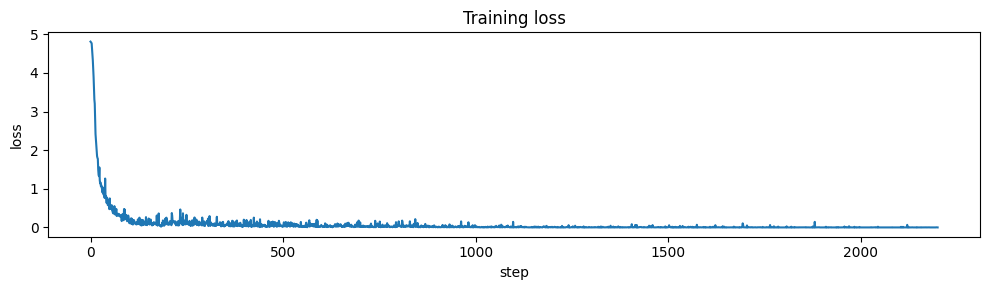

In [13]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

PLOT_EVERY = 50

# ── Data & training ───────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset   = NERDataset(data["text"].to_list(), data["target"].to_list())
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)

#model     = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)
#optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * 0.1), total_steps)

loss_history = []

def plot_loss(loss_history):
    clear_output(wait=True)
    plt.figure(figsize=(10, 3))
    plt.plot(loss_history)
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.tight_layout()
    plt.show()

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for step, batch in enumerate(dataloader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        loss  = model(**batch)["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        total_loss += loss.item()

        if (step + 1) % PLOT_EVERY == 0:
            plot_loss(loss_history)
            print(f"Epoch {epoch+1}/{EPOCHS} | step {step+1}/{len(dataloader)} | loss {loss.item():.4f}")

    print(f"── Epoch {epoch+1}/{EPOCHS} avg loss: {total_loss / len(dataloader):.4f}")

plot_loss(loss_history)


In [14]:
torch.save(model.state_dict(), "model.pth")
model.load_state_dict(torch.load("model.pth"))
df = pl.read_csv("/kaggle/input/competitions/llm-march2026-alfabank/private_test_dataset.csv")
df.head(5), df.shape

(shape: (5, 2)
 ┌─────┬─────────────────────────────────┐
 │ id  ┆ text                            │
 │ --- ┆ ---                             │
 │ i64 ┆ str                             │
 ╞═════╪═════════════════════════════════╡
 │ 0   ┆ Банкомат не запрашивает CVV-ко… │
 │ 1   ┆ Уточните, пожалуйста, ФИО полу… │
 │ 2   ┆ Проверьте папку «Спам» в вашей… │
 │ 3   ┆ Я пытаюсь обновить данные в ли… │
 │ 4   ┆ Хочу подключить СМС-информиров… │
 └─────┴─────────────────────────────────┘,
 (3552, 2))

In [17]:
model.eval()


def decode_triplets(pred_ids, offsets, attention_mask):
    triplets = []
    current_start = None
    current_end = None
    current_label = None

    def flush_current():
        nonlocal current_start, current_end, current_label
        if current_label is not None:
            triplets.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

    for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
        if mask == 0 or tok_start == tok_end:
            continue

        tag = bio_labels[int(pred_id)]
        if tag == "O":
            flush_current()
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B":
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        if current_label != label:
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        current_end = int(tok_end)

    flush_current()
    return triplets


@torch.no_grad()
def predict_triplets(texts, batch_size=64):
    all_triplets = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
            return_offsets_mapping=True,
        )

        offset_mapping = encoded.pop("offset_mapping")
        attention_mask = encoded["attention_mask"]
        batch = {k: v.to(DEVICE) for k, v in encoded.items()}

        outputs = model(**batch)
        ner_pred_ids = outputs["ner_logits"].argmax(dim=-1).cpu()
        cls_pred_ids = outputs["cls_logits"].argmax(dim=-1).cpu()

        for has_entity, pred_ids, offsets, mask in zip(
            cls_pred_ids.tolist(),
            ner_pred_ids.tolist(),
            offset_mapping.tolist(),
            attention_mask.tolist(),
        ):
            if has_entity == 0:
                all_triplets.append([])
                continue

            all_triplets.append(decode_triplets(pred_ids, offsets, mask))

    return all_triplets


pred_triplets = predict_triplets(df["text"].to_list())

# offset_mapping уже даёт символьные индексы токенов в исходной строке,
# поэтому для ответа берём первый start и последний end у непрерывного BIO-спана.
def format_prediction(triplets):
    if not triplets:
        return '[]'
    parts = [f"({int(s)}, {int(e)}, '{l}')" for s, e, l in triplets]
    return f'[{", ".join(parts)}]'


formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

submission_df = df.select("id", "text").with_columns(
    pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
)

In [18]:
submission_df.drop("text").write_csv("predictions.csv")
submission_df.head(10)

id,text,Prediction
i64,str,str
0,"""Банкомат не запрашивает CVV-ко…","""[]"""
1,"""Уточните, пожалуйста, ФИО полу…","""[(106, 124, 'Номер телефона')]"""
2,"""Проверьте папку «Спам» в вашей…","""[]"""
3,"""Я пытаюсь обновить данные в ли…","""[(88, 93, 'Паспортные данные')…"
4,"""Хочу подключить СМС-информиров…","""[(82, 94, 'Водительское удосто…"
5,"""Могу ли я закрыть счет по врем…","""[(51, 63, 'Временное удостовер…"
6,"""Проверьте, пожалуйста, нет ли …","""[]"""
7,"""Мой СНИЛС 300-400-500 05 не пр…","""[(10, 24, 'СНИЛС клиента')]"""
8,"""Я пытался расплатиться картой …","""[(57, 61, 'ПИН код')]"""


In [48]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME = "DeepPavlov/distilrubert-base-cased-conversational"
MAX_LENGTH  = 512
BATCH_SIZE  = 64
EPOCHS      = 15
LR          = 5e-4

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

# ── Entity classes ───────────────────────────────────────────────────────────
entity_labels = list(unique_labels)  # твой список классов
entity2id     = {lb: i for i, lb in enumerate(entity_labels)}
id2entity     = {i: lb for lb, i in entity2id.items()}
num_entity_classes = len(entity_labels)

# Локальная BIO-разметка для каждой отдельной головы
local_tag2id = {"O": 0, "B": 1, "I": 2}
id2local_tag = {v: k for k, v in local_tag2id.items()}

# Глобальная BIO-разметка — нужна для обратного декода/метрик
global_bio_labels   = ["O"] + [f"{p}-{lbl}" for lbl in entity_labels for p in ("B", "I")]
global_bio_label2id = {lb: i for i, lb in enumerate(global_bio_labels)}
global_bio_id2label = {i: lb for lb, i in global_bio_label2id.items()}

print(f"device: {DEVICE} | entity classes: {num_entity_classes}")

device: cuda | entity classes: 30


In [49]:
# ── Dataset ──────────────────────────────────────────────────────────────────
class NERDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts   = texts
        self.targets = [t if t else [] for t in targets]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.targets[idx]

In [50]:
# ── Collate for multi-head token classification ──────────────────────────────
def collate_fn_multihead(batch, tokenizer):
    texts, targets = zip(*batch)

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
        return_offsets_mapping=True,
    )
    offset_mappings = encoded.pop("offset_mapping")  # (B, T, 2)

    B, T = encoded["input_ids"].shape
    C = num_entity_classes

    # token_labels[b, t, c] ∈ {-100, 0, 1, 2}
    # -100 -> special/pad token
    # 0    -> O
    # 1    -> B
    # 2    -> I
    token_labels = torch.full((B, T, C), -100, dtype=torch.long)

    # multi-label presence per class: (B, C)
    class_labels = torch.zeros((B, C), dtype=torch.float32)

    # бинарный признак "в тексте есть хоть одна сущность"
    binary_labels = torch.zeros(B, dtype=torch.long)

    for i, (spans, offsets) in enumerate(zip(targets, offset_mappings)):
        if spans:
            binary_labels[i] = 1

        # spans: [(span_start, span_end, label_id), ...]
        for t, (tok_start, tok_end) in enumerate(offsets.tolist()):
            if tok_start == tok_end:
                # special token / padding
                continue

            # по умолчанию для всех голов это O
            token_labels[i, t, :] = 0

            # если токен попал в сущность, только соответствующая голова получает B/I
            for span_start, span_end, label_id in spans:
                if tok_start < span_end and tok_end > span_start:
                    token_labels[i, t, label_id] = 1 if tok_start <= span_start else 2
                    class_labels[i, label_id] = 1.0
                    break

    encoded["token_labels"] = token_labels
    encoded["class_labels"] = class_labels
    encoded["binary_labels"] = binary_labels
    return encoded

In [51]:
# ── Model ────────────────────────────────────────────────────────────────────
class MultiHeadNER(nn.Module):
    def __init__(
        self,
        model_name,
        num_entity_classes,
        neg_doc_weight=0.25,        # меньше весим документы, где класса нет
        presence_loss_weight=0.20,  # вес auxiliary multi-label head
        any_loss_weight=0.10        # вес binary head
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size

        # Отдельная token-head на каждый класс: O / B / I
        self.token_heads = nn.ModuleList([
            nn.Linear(h, 3) for _ in range(num_entity_classes)
        ])

        # multi-label presence head: какие классы есть в тексте
        self.class_presence_head = nn.Linear(h, num_entity_classes)

        # бинарная голова: есть вообще сущности или нет
        self.any_entity_head = nn.Linear(h, 2)

        self.num_entity_classes = num_entity_classes
        self.neg_doc_weight = neg_doc_weight
        self.presence_loss_weight = presence_loss_weight
        self.any_loss_weight = any_loss_weight

        self.token_ce = nn.CrossEntropyLoss(ignore_index=-100, reduction="none")
        self.presence_bce = nn.BCEWithLogitsLoss()
        self.any_ce = nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids,
        attention_mask,
        token_labels=None,
        class_labels=None,
        binary_labels=None,
        **kwargs
    ):
        hidden = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state  # (B, T, H)

        cls_hidden = hidden[:, 0]  # (B, H)

        # (B, T, C, 3)
        token_logits = torch.stack(
            [head(hidden) for head in self.token_heads],
            dim=2
        )

        # (B, C)
        class_logits = self.class_presence_head(cls_hidden)

        # (B, 2)
        any_logits = self.any_entity_head(cls_hidden)

        loss = None
        token_loss = None
        presence_loss = None
        any_loss = None

        if token_labels is not None:
            B, T, C, _ = token_logits.shape
            per_head_losses = []

            # Считаем loss отдельно по каждой голове
            for c in range(C):
                logits_c = token_logits[:, :, c, :].contiguous().view(-1, 3)   # (B*T, 3)
                labels_c = token_labels[:, :, c].contiguous().view(-1)          # (B*T,)

                raw_loss_c = self.token_ce(logits_c, labels_c).view(B, T)       # (B, T)

                valid_mask_c = (token_labels[:, :, c] != -100).float()          # (B, T)
                loss_per_doc_c = (raw_loss_c * valid_mask_c).sum(dim=1) / valid_mask_c.sum(dim=1).clamp_min(1.0)

                # Если класса в документе нет, уменьшаем вес такого документа для данной головы
                doc_weights_c = torch.where(
                    class_labels[:, c] > 0,
                    torch.ones_like(class_labels[:, c]),
                    torch.full_like(class_labels[:, c], self.neg_doc_weight)
                )

                loss_c = (loss_per_doc_c * doc_weights_c).mean()
                per_head_losses.append(loss_c)

            token_loss = torch.stack(per_head_losses).mean()

            presence_loss = self.presence_bce(class_logits, class_labels.float())
            any_loss = self.any_ce(any_logits, binary_labels.long())

            loss = token_loss \
                 + self.presence_loss_weight * presence_loss \
                 + self.any_loss_weight * any_loss

        return {
            "loss": loss,
            "token_loss": token_loss,
            "presence_loss": presence_loss,
            "any_loss": any_loss,
            "token_logits": token_logits,     # (B, T, C, 3)
            "class_logits": class_logits,     # (B, C)
            "any_logits": any_logits          # (B, 2)
        }

In [52]:
# ── Freeze helpers ───────────────────────────────────────────────────────────
def get_encoder_layers(encoder):
    # DistilBERT-like
    if hasattr(encoder, "transformer") and hasattr(encoder.transformer, "layer"):
        return encoder.transformer.layer

    # BERT-like
    if hasattr(encoder, "encoder") and hasattr(encoder.encoder, "layer"):
        return encoder.encoder.layer

    raise AttributeError("Не нашёл список encoder layers у этой модели.")

def freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3):
    if freeze_embeddings and hasattr(model.encoder, "embeddings"):
        for p in model.encoder.embeddings.parameters():
            p.requires_grad = False

    layers = get_encoder_layers(model.encoder)
    for i, layer in enumerate(layers):
        if i < freeze_n_layers:
            for p in layer.parameters():
                p.requires_grad = False

def print_trainable_parameters(model):
    total = 0
    trainable = 0

    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            print(f"TRAINABLE: {name}")

    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {100 * trainable / total:.2f}%")

In [53]:
model = MultiHeadNER(
    model_name=MODEL_NAME,
    num_entity_classes=num_entity_classes,
    neg_doc_weight=0.25,
    presence_loss_weight=0.20,
    any_loss_weight=0.10
).to(DEVICE)

freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3)
print_trainable_parameters(model)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: DeepPavlov/distilrubert-base-cased-conversational
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TRAINABLE: encoder.transformer.layer.3.attention.q_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.q_lin.bias
TRAINABLE: encoder.transformer.layer.3.attention.k_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.k_lin.bias
TRAINABLE: encoder.transformer.layer.3.attention.v_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.v_lin.bias
TRAINABLE: encoder.transformer.layer.3.attention.out_lin.weight
TRAINABLE: encoder.transformer.layer.3.attention.out_lin.bias
TRAINABLE: encoder.transformer.layer.3.sa_layer_norm.weight
TRAINABLE: encoder.transformer.layer.3.sa_layer_norm.bias
TRAINABLE: encoder.transformer.layer.3.ffn.lin1.weight
TRAINABLE: encoder.transformer.layer.3.ffn.lin1.bias
TRAINABLE: encoder.transformer.layer.3.ffn.lin2.weight
TRAINABLE: encoder.transformer.layer.3.ffn.lin2.bias
TRAINABLE: encoder.transformer.layer.3.output_layer_norm.weight
TRAINABLE: encoder.transformer.layer.3.output_layer_norm.bias
TRAINABLE: encoder.transformer.layer.4.attention

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

PLOT_EVERY = 50

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset = NERDataset(data["text"].to_list(), data["target"].to_list())

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda b: collate_fn_multihead(b, tokenizer),
)

total_steps = len(dataloader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    int(total_steps * 0.1),
    total_steps
)

loss_history = []
token_loss_history = []
presence_loss_history = []
any_loss_history = []

def plot_loss(loss_history, token_loss_history=None, presence_loss_history=None, any_loss_history=None):
    clear_output(wait=True)
    plt.figure(figsize=(12, 4))
    plt.plot(loss_history, label="total_loss")

    if token_loss_history is not None and len(token_loss_history) > 0:
        plt.plot(token_loss_history, label="token_loss")
    if presence_loss_history is not None and len(presence_loss_history) > 0:
        plt.plot(presence_loss_history, label="presence_loss")
    if any_loss_history is not None and len(any_loss_history) > 0:
        plt.plot(any_loss_history, label="any_loss")

    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0

    for step, batch in enumerate(dataloader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        out = model(**batch)
        loss = out["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        token_loss_history.append(out["token_loss"].item())
        presence_loss_history.append(out["presence_loss"].item())
        any_loss_history.append(out["any_loss"].item())

        total_loss += loss.item()

        if (step + 1) % PLOT_EVERY == 0:
            plot_loss(
                loss_history,
                token_loss_history,
                presence_loss_history,
                any_loss_history
            )
            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"step {step+1}/{len(dataloader)} | "
                f"loss={loss.item():.4f} | "
                f"token={out['token_loss'].item():.4f} | "
                f"presence={out['presence_loss'].item():.4f} | "
                f"any={out['any_loss'].item():.4f}"
            )

    print(f"── Epoch {epoch+1}/{EPOCHS} avg loss: {total_loss / len(dataloader):.4f}")

plot_loss(
    loss_history,
    token_loss_history,
    presence_loss_history,
    any_loss_history
)

In [55]:
# ── Decode multi-head logits to global BIO ids ───────────────────────────────
@torch.no_grad()
def multihead_logits_to_global_ids(
    token_logits,          # (B, T, C, 3)
    class_logits=None,     # (B, C)
    attention_mask=None,   # (B, T)
    token_threshold=0.50,
    class_threshold=0.50
):
    probs = torch.softmax(token_logits, dim=-1)       # (B, T, C, 3)
    non_o_probs = probs[..., 1:]                      # (B, T, C, 2)

    # Для каждого класса на каждом токене берём max(B, I)
    entity_scores, bi_choice = non_o_probs.max(dim=-1)   # (B, T, C), (B, T, C)

    # Если есть class head — гейтируем по нему
    if class_logits is not None:
        class_mask = (torch.sigmoid(class_logits) >= class_threshold).float()  # (B, C)
        entity_scores = entity_scores * class_mask.unsqueeze(1)

    # Лучший класс на каждом токене
    best_class = entity_scores.argmax(dim=-1)  # (B, T)

    best_score = entity_scores.gather(-1, best_class.unsqueeze(-1)).squeeze(-1)  # (B, T)
    best_bi = bi_choice.gather(-1, best_class.unsqueeze(-1)).squeeze(-1) + 1      # 1=B, 2=I

    # 0 = O
    pred_global_ids = torch.zeros_like(best_class, dtype=torch.long)

    entity_mask = best_score >= token_threshold

    # Глобальный id:
    # O -> 0
    # B-class0 -> 1
    # I-class0 -> 2
    # B-class1 -> 3
    # I-class1 -> 4
    pred_global_ids[entity_mask] = 1 + 2 * best_class[entity_mask] + (best_bi[entity_mask] - 1)

    # padding можно принудительно в O
    if attention_mask is not None:
        pred_global_ids = pred_global_ids * attention_mask.long()

    return pred_global_ids

In [56]:
import torch
import polars as pl

SAVE_PATH = "multihead_ner_model.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "entity_labels": entity_labels,
        "num_entity_classes": num_entity_classes,
    },
    SAVE_PATH
)

In [57]:
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)

entity_labels = ckpt["entity_labels"]
entity2id = {lb: i for i, lb in enumerate(entity_labels)}
id2entity = {i: lb for lb, i in entity2id.items()}
num_entity_classes = ckpt["num_entity_classes"]
MODEL_NAME = ckpt["model_name"]
MAX_LENGTH = ckpt["max_length"]

global_bio_labels = ["O"] + [f"{p}-{lbl}" for lbl in entity_labels for p in ("B", "I")]
global_bio_label2id = {lb: i for i, lb in enumerate(global_bio_labels)}
global_bio_id2label = {i: lb for lb, i in global_bio_label2id.items()}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = MultiHeadNER(
    model_name=MODEL_NAME,
    num_entity_classes=num_entity_classes,
    neg_doc_weight=0.25,
    presence_loss_weight=0.20,
    any_loss_weight=0.10
).to(DEVICE)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: DeepPavlov/distilrubert-base-cased-conversational
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultiHeadNER(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linea

In [58]:
@torch.no_grad()
def multihead_logits_to_global_ids(
    token_logits,          # (B, T, C, 3)
    class_logits=None,     # (B, C)
    attention_mask=None,   # (B, T)
    token_threshold=0.50,
    class_threshold=0.50,
    use_class_gating=True
):
    # Вероятности по O/B/I внутри каждой головы
    probs = torch.softmax(token_logits, dim=-1)          # (B, T, C, 3)

    # Берём только B/I
    non_o_probs = probs[..., 1:]                         # (B, T, C, 2)

    # Для каждого класса на токене: лучший из B/I
    entity_scores, bi_choice = non_o_probs.max(dim=-1)   # (B, T, C), (B, T, C)
    # bi_choice: 0 -> B, 1 -> I

    # Доп. гейтинг по class_presence_head
    if use_class_gating and class_logits is not None:
        class_mask = (torch.sigmoid(class_logits) >= class_threshold).float()   # (B, C)
        entity_scores = entity_scores * class_mask.unsqueeze(1)

    # Лучший класс на токене
    best_class = entity_scores.argmax(dim=-1)            # (B, T)
    best_score = entity_scores.gather(-1, best_class.unsqueeze(-1)).squeeze(-1)  # (B, T)
    best_bi = bi_choice.gather(-1, best_class.unsqueeze(-1)).squeeze(-1) + 1      # 1=B, 2=I

    # По умолчанию O
    pred_global_ids = torch.zeros_like(best_class, dtype=torch.long)

    # Если уверенности хватает — ставим B/I выбранного класса
    entity_mask = best_score >= token_threshold

    # Глобальная кодировка:
    # O = 0
    # B-class0 = 1
    # I-class0 = 2
    # B-class1 = 3
    # I-class1 = 4
    pred_global_ids[entity_mask] = 1 + 2 * best_class[entity_mask] + (best_bi[entity_mask] - 1)

    if attention_mask is not None:
        pred_global_ids = pred_global_ids * attention_mask.long()

    return pred_global_ids

In [59]:
def decode_triplets(pred_ids, offsets, attention_mask):
    triplets = []
    current_start = None
    current_end = None
    current_label = None

    def flush_current():
        nonlocal current_start, current_end, current_label
        if current_label is not None:
            triplets.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

    for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
        if mask == 0 or tok_start == tok_end:
            continue

        tag = global_bio_labels[int(pred_id)]

        if tag == "O":
            flush_current()
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B":
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        # prefix == "I"
        if current_label != label:
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        current_end = int(tok_end)

    flush_current()
    return triplets

In [60]:
@torch.no_grad()
def predict_triplets_multihead(
    texts,
    batch_size=64,
    token_threshold=0.50,
    class_threshold=0.50,
    use_class_gating=True,
    use_any_head=True
):
    all_triplets = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
            return_offsets_mapping=True,
        )

        offset_mapping = encoded.pop("offset_mapping")          # CPU
        attention_mask_cpu = encoded["attention_mask"].clone()  # CPU copy

        batch = {k: v.to(DEVICE) for k, v in encoded.items()}

        outputs = model(**batch)

        token_logits = outputs["token_logits"]   # (B, T, C, 3)
        class_logits = outputs["class_logits"]   # (B, C)
        any_logits = outputs["any_logits"]       # (B, 2)

        pred_global_ids = multihead_logits_to_global_ids(
            token_logits=token_logits,
            class_logits=class_logits,
            attention_mask=batch["attention_mask"],
            token_threshold=token_threshold,
            class_threshold=class_threshold,
            use_class_gating=use_class_gating
        ).cpu()

        if use_any_head:
            any_pred_ids = any_logits.argmax(dim=-1).cpu()
        else:
            any_pred_ids = torch.ones(pred_global_ids.shape[0], dtype=torch.long)

        for has_entity, pred_ids, offsets, mask in zip(
            any_pred_ids.tolist(),
            pred_global_ids.tolist(),
            offset_mapping.tolist(),
            attention_mask_cpu.tolist(),
        ):
            if use_any_head and has_entity == 0:
                all_triplets.append([])
                continue

            triplets = decode_triplets(pred_ids, offsets, mask)
            all_triplets.append(triplets)

    return all_triplets

In [61]:
df = pl.read_csv("/kaggle/input/competitions/llm-march2026-alfabank/private_test_dataset.csv")
print(df.head(5))
print(df.shape)

shape: (5, 2)
┌─────┬─────────────────────────────────┐
│ id  ┆ text                            │
│ --- ┆ ---                             │
│ i64 ┆ str                             │
╞═════╪═════════════════════════════════╡
│ 0   ┆ Банкомат не запрашивает CVV-ко… │
│ 1   ┆ Уточните, пожалуйста, ФИО полу… │
│ 2   ┆ Проверьте папку «Спам» в вашей… │
│ 3   ┆ Я пытаюсь обновить данные в ли… │
│ 4   ┆ Хочу подключить СМС-информиров… │
└─────┴─────────────────────────────────┘
(3552, 2)


In [62]:
pred_triplets = predict_triplets_multihead(
    df["text"].to_list(),
    batch_size=64,
    token_threshold=0.50,
    class_threshold=0.50,
    use_class_gating=True,
    use_any_head=True
)

In [63]:
def format_prediction(triplets):
    if not triplets:
        return "[]"
    parts = [f"({int(s)}, {int(e)}, '{l}')" for s, e, l in triplets]
    return f"[{', '.join(parts)}]"

In [64]:
formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

submission_df = df.select("id", "text").with_columns(
    pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
)

submission_df.head(10)

id,text,Prediction
i64,str,str
0,"""Банкомат не запрашивает CVV-ко…","""[]"""
1,"""Уточните, пожалуйста, ФИО полу…","""[(106, 124, 'Номер телефона')]"""
2,"""Проверьте папку «Спам» в вашей…","""[]"""
3,"""Я пытаюсь обновить данные в ли…","""[(88, 93, 'Паспортные данные')…"
4,"""Хочу подключить СМС-информиров…","""[(82, 94, 'Водительское удосто…"
5,"""Могу ли я закрыть счет по врем…","""[(51, 63, 'Временное удостовер…"
6,"""Проверьте, пожалуйста, нет ли …","""[]"""
7,"""Мой СНИЛС 300-400-500 05 не пр…","""[(10, 24, 'СНИЛС клиента')]"""
8,"""Я пытался расплатиться картой …","""[(57, 61, 'ПИН код')]"""


In [65]:
submission_df.drop("text").write_csv("predictions.csv")

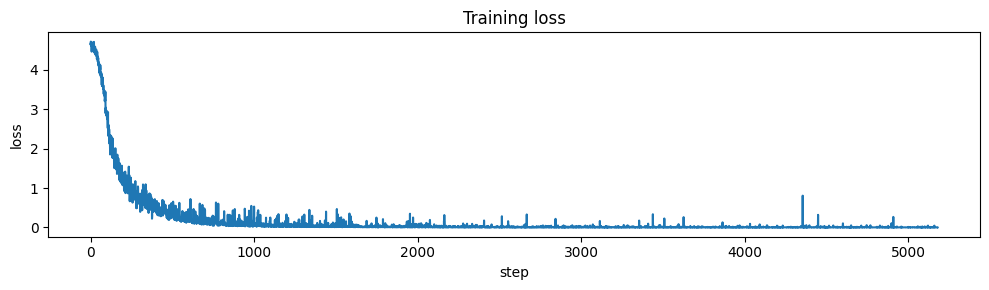

Saved checkpoint to: rubert_base_conversational_bio_multitask.pt
shape: (5, 2)
┌─────┬─────────────────────────────────┐
│ id  ┆ text                            │
│ --- ┆ ---                             │
│ i64 ┆ str                             │
╞═════╪═════════════════════════════════╡
│ 0   ┆ Банкомат не запрашивает CVV-ко… │
│ 1   ┆ Уточните, пожалуйста, ФИО полу… │
│ 2   ┆ Проверьте папку «Спам» в вашей… │
│ 3   ┆ Я пытаюсь обновить данные в ли… │
│ 4   ┆ Хочу подключить СМС-информиров… │
└─────┴─────────────────────────────────┘
private test shape: (3552, 2)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint loaded successfully
shape: (10, 3)
┌─────┬─────────────────────────────────┬─────────────────────────────────┐
│ id  ┆ text                            ┆ Prediction                      │
│ --- ┆ ---                             ┆ ---                             │
│ i64 ┆ str                             ┆ str                             │
╞═════╪═════════════════════════════════╪═════════════════════════════════╡
│ 0   ┆ Банкомат не запрашивает CVV-ко… ┆ []                              │
│ 1   ┆ Уточните, пожалуйста, ФИО полу… ┆ [(106, 124, 'Номер телефона')]  │
│ 2   ┆ Проверьте папку «Спам» в вашей… ┆ []                              │
│ 3   ┆ Я пытаюсь обновить данные в ли… ┆ [(88, 93, 'Паспортные данные')… │
│ 4   ┆ Хочу подключить СМС-информиров… ┆ [(82, 94, 'Водительское удосто… │
│ 5   ┆ Могу ли я закрыть счет по врем… ┆ [(51, 63, 'Временное удостовер… │
│ 6   ┆ Проверьте, пожалуйста, нет ли … ┆ []                              │
│ 7   ┆ Мой СНИЛС 300-400-500 05 не пр… ┆ 

In [3]:
# =========================================
# 1. REPRODUCIBILITY SETUP
# =========================================
import os
SEED = 889
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import math
import random
import re
import json
import hashlib
from contextlib import nullcontext

import numpy as np
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
from IPython.display import clear_output


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as e:
        print("torch.use_deterministic_algorithms warning:", e)


seed_everything(SEED)

FORCE_CPU_FOR_FULL_REPRO = False
if FORCE_CPU_FOR_FULL_REPRO:
    DEVICE = "cpu"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

USE_AMP = (DEVICE == "cuda")


def autocast_context(device: str, enabled: bool):
    if device == "cuda":
        return torch.amp.autocast("cuda", enabled=enabled)
    return nullcontext()


print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)
print("SEED:", SEED)

# =========================================
# 2. CONFIG
# =========================================
MODEL_NAME = "DeepPavlov/rubert-base-cased-conversational"

MAX_LENGTH = 512

# Для rubert-base-conversational BATCH_SIZE=64 на Kaggle — слишком жирно.
# Ниже более реалистичный старт.
BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 4

EPOCHS = 10
LR = 5e-5
WEIGHT_DECAY = 0.01

FREEZE_EMBEDDINGS = True
FREEZE_N_LAYERS = 6

TRAIN_PATH = "/kaggle/input/competitions/llm-march2026-alfabank/train_dataset.tsv"
TEST_PATH = "/kaggle/input/competitions/llm-march2026-alfabank/private_test_dataset.csv"

CHECKPOINT_PATH = "rubert_base_conversational_bio_multitask.pt"
PRED_PATH = "predictions.csv"
META_PATH = "run_metadata.json"

# =========================================
# 3. LOAD TRAIN DATA
# =========================================
data = pl.read_csv(TRAIN_PATH, separator="\t")
print(data.head(5))
print("train shape:", data.shape)

# =========================================
# 4. EXTRACT LABELS
# =========================================
labels = (
    data
    .filter(pl.col("target") != "[]")
    .select(
        pl.col("target")
        .str.extract_all(r"'([^']+)'")
        .explode()
        .alias("label")
    )
)

label_counts = (
    labels
    .group_by("label")
    .len()
    .sort("len", descending=True)
)

print(f"Всего уникальных меток: {label_counts.shape[0]}\n")
print(label_counts)

empty_count = data.filter(pl.col("target") == "[]").shape[0]
print(f"\nСтрок без меток: {empty_count} из {data.shape[0]} ({empty_count / data.shape[0] * 100:.1f}%)")

# =========================================
# 5. MAP TARGET TO [[start, end, label_id], ...]
# =========================================
unique_labels = sorted(lb.strip("'") for lb in label_counts["label"].to_list())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {v: k for k, v in label2id.items()}

pattern = re.compile(r"\((\d+),\s*(\d+),\s*'([^']+)'\)")

data = data.with_columns(
    pl.col("target").map_elements(
        lambda s: [[int(a), int(b), label2id[c]] for a, b, c in pattern.findall(s)],
        return_dtype=pl.List(pl.List(pl.Int64))
    ).alias("target")
)

print(data.select("text", "target").head(10))

# =========================================
# 6. LABEL DISTRIBUTION AFTER MAPPING
# =========================================
label_dist = (
    data.select(pl.col("target").explode().alias("span"))
    .filter(pl.col("span").is_not_null())
    .select(pl.col("span").list.get(2).alias("label_id"))
    .group_by("label_id")
    .len()
    .sort("len", descending=True)
    .with_columns(pl.col("label_id").replace_strict(id2label).alias("label"))
    .select("label_id", "label", "len")
)

print(f"Уникальных меток: {label_dist.shape[0]}")
print(label_dist)

# =========================================
# 7. BIO LABELS
# =========================================
bio_labels = ["O"] + [f"{p}-{lbl}" for lbl in unique_labels for p in ("B", "I")]
bio_label2id = {lb: i for i, lb in enumerate(bio_labels)}
bio_id2label = {i: lb for lb, i in bio_label2id.items()}
num_ner_labels = len(bio_labels)

print(f"NER labels: {num_ner_labels}")

# =========================================
# 8. DATASET
# =========================================
class NERDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts = texts
        self.targets = [t if t else [] for t in targets]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.targets[idx]

# =========================================
# 9. COLLATE
# =========================================
def collate_fn(batch, tokenizer):
    texts, targets = zip(*batch)

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
        return_offsets_mapping=True,
    )

    offset_mappings = encoded.pop("offset_mapping")

    # Оставляем только нужные поля
    model_inputs = {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
    }

    token_labels_batch = []
    binary_labels_batch = []

    for spans, offsets in zip(targets, offset_mappings):
        binary_labels_batch.append(1 if spans else 0)
        token_labels = []

        for tok_start, tok_end in offsets.tolist():
            if tok_start == tok_end:
                token_labels.append(-100)
                continue

            label = bio_label2id["O"]

            for span_start, span_end, label_id in spans:
                if tok_start < span_end and tok_end > span_start:
                    name = unique_labels[label_id]
                    label = bio_label2id[f"B-{name}" if tok_start <= span_start else f"I-{name}"]
                    break

            token_labels.append(label)

        token_labels_batch.append(token_labels)

    model_inputs["labels"] = torch.tensor(token_labels_batch, dtype=torch.long)
    model_inputs["binary_labels"] = torch.tensor(binary_labels_batch, dtype=torch.long)

    return model_inputs

# =========================================
# 10. MODEL
# =========================================
def masked_mean_pooling(hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (hidden * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-6)
    return summed / denom


class MultiTaskNER(nn.Module):
    def __init__(self, model_name, num_ner_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.ner_head = nn.Linear(h, num_ner_labels)
        self.cls_head = nn.Linear(h, 2)

    def forward(self, input_ids, attention_mask, labels=None, binary_labels=None, **kwargs):
        hidden = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state

        hidden = self.dropout(hidden)
        ner_logits = self.ner_head(hidden)  # (B, T, C)

        pooled = masked_mean_pooling(hidden, attention_mask)
        cls_logits = self.cls_head(pooled)  # (B, 2)

        loss = None
        if labels is not None and binary_labels is not None:
            cls_loss = nn.CrossEntropyLoss()(cls_logits, binary_labels)

            pos_mask = binary_labels == 1
            if pos_mask.any():
                ner_loss = nn.CrossEntropyLoss(ignore_index=-100)(
                    ner_logits[pos_mask].reshape(-1, num_ner_labels),
                    labels[pos_mask].reshape(-1),
                )
                loss = cls_loss + ner_loss
            else:
                loss = cls_loss

        return {
            "loss": loss,
            "ner_logits": ner_logits,
            "cls_logits": cls_logits,
        }

# =========================================
# 11. FREEZE HELPERS
# =========================================
def freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3):
    for name, p in model.encoder.named_parameters():
        should_freeze = False

        if freeze_embeddings and "embeddings" in name:
            should_freeze = True

        for i in range(freeze_n_layers):
            layer_patterns = [
                f"encoder.layer.{i}.",
                f"transformer.layer.{i}.",
                f"layer.{i}.",
            ]
            if any(lp in name for lp in layer_patterns):
                should_freeze = True
                break

        if should_freeze:
            p.requires_grad = False


def print_trainable_parameters(model):
    total = 0
    trainable = 0
    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            print(f"TRAINABLE: {name}")
    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params: {total:,}")
    print(f"Trainable %: {100 * trainable / total:.2f}%")

# =========================================
# 12. TOKENIZER / DATASET / DATALOADER
# =========================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

dataset = NERDataset(
    texts=data["text"].to_list(),
    targets=data["target"].to_list()
)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=train_generator,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)

print("Num batches:", len(dataloader))

# =========================================
# 13. MODEL INIT
# =========================================
seed_everything(SEED)

model = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)

freeze_encoder_layers(
    model,
    freeze_embeddings=FREEZE_EMBEDDINGS,
    freeze_n_layers=FREEZE_N_LAYERS,
)

print_trainable_parameters(model)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

total_steps = math.ceil(len(dataloader) / GRAD_ACCUM_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP) if DEVICE == "cuda" else None

# =========================================
# 14. TRAIN
# =========================================
PLOT_EVERY = 50
loss_history = []

def plot_loss(loss_history):
    clear_output(wait=True)
    plt.figure(figsize=(10, 3))
    plt.plot(loss_history)
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.tight_layout()
    plt.show()

model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(dataloader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with autocast_context(DEVICE, USE_AMP):
            outputs = model(**batch)
            loss = outputs["loss"] / GRAD_ACCUM_STEPS

        if DEVICE == "cuda" and scaler is not None:
            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(dataloader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
        else:
            loss.backward()

            if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(dataloader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

        loss_value = float(outputs["loss"].item())
        loss_history.append(loss_value)
        total_loss += loss_value

        if (step + 1) % PLOT_EVERY == 0:
            plot_loss(loss_history)
            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"step {step+1}/{len(dataloader)} | "
                f"loss {loss_value:.4f} | "
                f"lr {scheduler.get_last_lr()[0]:.2e}"
            )

    avg_loss = total_loss / len(dataloader)
    print(f"── Epoch {epoch+1}/{EPOCHS} avg loss: {avg_loss:.4f}")

plot_loss(loss_history)

# =========================================
# 15. SAVE FULL CHECKPOINT
# =========================================
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "seed": SEED,
    "freeze_embeddings": FREEZE_EMBEDDINGS,
    "freeze_n_layers": FREEZE_N_LAYERS,
    "unique_labels": unique_labels,
    "label2id": label2id,
    "id2label": id2label,
    "bio_labels": bio_labels,
    "bio_label2id": bio_label2id,
    "bio_id2label": bio_id2label,
    "device_used_for_training": DEVICE,
    "loss_history": loss_history,
}
torch.save(checkpoint, CHECKPOINT_PATH)
print(f"Saved checkpoint to: {CHECKPOINT_PATH}")

# =========================================
# 16. LOAD PRIVATE TEST
# =========================================
df_test = pl.read_csv(TEST_PATH)
print(df_test.head(5))
print("private test shape:", df_test.shape)

# =========================================
# 17. LOAD CHECKPOINT FOR INFERENCE
# =========================================
seed_everything(SEED)

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

MODEL_NAME_INF = ckpt["model_name"]
MAX_LENGTH_INF = ckpt["max_length"]
unique_labels_inf = ckpt["unique_labels"]
label2id_inf = ckpt["label2id"]
id2label_inf = ckpt["id2label"]
bio_labels_inf = ckpt["bio_labels"]
bio_label2id_inf = ckpt["bio_label2id"]
bio_id2label_inf = ckpt["bio_id2label"]

tokenizer_inf = AutoTokenizer.from_pretrained(MODEL_NAME_INF, use_fast=True)
model_inf = MultiTaskNER(MODEL_NAME_INF, len(bio_labels_inf)).to(DEVICE)
model_inf.load_state_dict(ckpt["model_state_dict"])
model_inf.eval()
print("Checkpoint loaded successfully")

# =========================================
# 18. DECODE
# =========================================
def decode_triplets(pred_ids, offsets, attention_mask, bio_labels):
    triplets = []
    current_start = None
    current_end = None
    current_label = None

    def flush_current():
        nonlocal current_start, current_end, current_label
        if current_label is not None:
            triplets.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

    for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
        if mask == 0 or tok_start == tok_end:
            continue

        tag = bio_labels[int(pred_id)]

        if tag == "O":
            flush_current()
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B":
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        if current_label != label:
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        current_end = int(tok_end)

    flush_current()
    return triplets

# =========================================
# 19. PREDICT
# =========================================
@torch.no_grad()
def predict_triplets(texts, model, tokenizer, bio_labels, max_length, device, batch_size=16):
    all_triplets = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            return_offsets_mapping=True,
        )

        offset_mapping = encoded.pop("offset_mapping")
        attention_mask = encoded["attention_mask"]

        batch = {
            "input_ids": encoded["input_ids"].to(device),
            "attention_mask": encoded["attention_mask"].to(device),
        }

        with autocast_context(device, USE_AMP):
            outputs = model(**batch)

        ner_pred_ids = outputs["ner_logits"].argmax(dim=-1).cpu()
        cls_pred_ids = outputs["cls_logits"].argmax(dim=-1).cpu()

        for has_entity, pred_ids, offsets, mask in zip(
            cls_pred_ids.tolist(),
            ner_pred_ids.tolist(),
            offset_mapping.tolist(),
            attention_mask.tolist(),
        ):
            if has_entity == 0:
                all_triplets.append([])
                continue

            all_triplets.append(
                decode_triplets(
                    pred_ids=pred_ids,
                    offsets=offsets,
                    attention_mask=mask,
                    bio_labels=bio_labels,
                )
            )

    return all_triplets

# =========================================
# 20. FORMAT SUBMISSION
# =========================================
def format_prediction(triplets):
    if not triplets:
        return "[]"
    parts = [f"({int(s)}, {int(e)}, '{label}')" for s, e, label in triplets]
    return f"[{', '.join(parts)}]"

# =========================================
# 21. RUN INFERENCE
# =========================================
pred_triplets = predict_triplets(
    texts=df_test["text"].to_list(),
    model=model_inf,
    tokenizer=tokenizer_inf,
    bio_labels=bio_labels_inf,
    max_length=MAX_LENGTH_INF,
    device=DEVICE,
    batch_size=16,
)

formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

submission_df = df_test.select("id", "text").with_columns(
    pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
)

submission_df.drop("text").write_csv(PRED_PATH)
print(submission_df.head(10))
print(f"Saved predictions to: {PRED_PATH}")

# =========================================
# 22. HASH FOR REPRO CHECK
# =========================================
pred_blob = "\n".join(formatted_predictions).encode("utf-8")
pred_md5 = hashlib.md5(pred_blob).hexdigest()
print("Predictions MD5:", pred_md5)

# =========================================
# 23. SAVE METADATA JSON
# =========================================
metadata = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "freeze_embeddings": FREEZE_EMBEDDINGS,
    "freeze_n_layers": FREEZE_N_LAYERS,
    "device": DEVICE,
    "use_amp": USE_AMP,
    "num_train_rows": data.shape[0],
    "num_test_rows": df_test.shape[0],
    "num_unique_labels": len(unique_labels),
    "predictions_md5": pred_md5,
}

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Saved {META_PATH}")

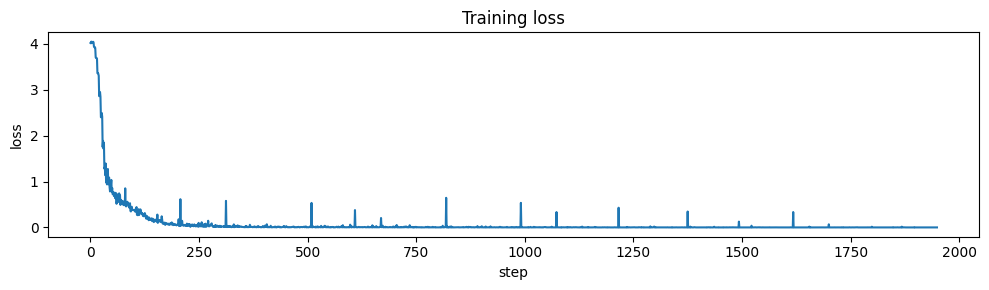

Saved checkpoint to: distilrubert.pt
shape: (5, 2)
┌─────┬─────────────────────────────────┐
│ id  ┆ text                            │
│ --- ┆ ---                             │
│ i64 ┆ str                             │
╞═════╪═════════════════════════════════╡
│ 0   ┆ Банкомат не запрашивает CVV-ко… │
│ 1   ┆ Уточните, пожалуйста, ФИО полу… │
│ 2   ┆ Проверьте папку «Спам» в вашей… │
│ 3   ┆ Я пытаюсь обновить данные в ли… │
│ 4   ┆ Хочу подключить СМС-информиров… │
└─────┴─────────────────────────────────┘
private test shape: (3552, 2)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: DeepPavlov/distilrubert-base-cased-conversational
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint loaded successfully
shape: (10, 3)
┌─────┬─────────────────────────────────┬─────────────────────────────────┐
│ id  ┆ text                            ┆ Prediction                      │
│ --- ┆ ---                             ┆ ---                             │
│ i64 ┆ str                             ┆ str                             │
╞═════╪═════════════════════════════════╪═════════════════════════════════╡
│ 0   ┆ Банкомат не запрашивает CVV-ко… ┆ []                              │
│ 1   ┆ Уточните, пожалуйста, ФИО полу… ┆ [(106, 124, 'Номер телефона')]  │
│ 2   ┆ Проверьте папку «Спам» в вашей… ┆ []                              │
│ 3   ┆ Я пытаюсь обновить данные в ли… ┆ [(88, 93, 'Паспортные данные')… │
│ 4   ┆ Хочу подключить СМС-информиров… ┆ [(82, 94, 'Водительское удосто… │
│ 5   ┆ Могу ли я закрыть счет по врем… ┆ [(51, 63, 'Временное удостовер… │
│ 6   ┆ Проверьте, пожалуйста, нет ли … ┆ []                              │
│ 7   ┆ Мой СНИЛС 300-400-500 05 не пр… ┆ 

In [1]:
# =========================================
# 1. REPRODUCIBILITY SETUP
# =========================================
import os
SEED = 404
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import math
import random
import re
import json
import hashlib
from contextlib import nullcontext
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
from IPython.display import clear_output

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        if torch.backends.cudnn.is_available():
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as e:
        print("torch.use_deterministic_algorithms warning:", e)

seed_everything(SEED)

FORCE_CPU_FOR_FULL_REPRO = False
if FORCE_CPU_FOR_FULL_REPRO:
    DEVICE = "cpu"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
USE_AMP = (DEVICE == "cuda")

def autocast_context(device: str, enabled: bool):
    if device == "cuda":
        return torch.amp.autocast("cuda", enabled=enabled)
    return nullcontext()

print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)
print("SEED:", SEED)

# =========================================
# 2. CONFIG
# =========================================
MODEL_NAME = "DeepPavlov/distilrubert-base-cased-conversational"
MAX_LENGTH = 512
BATCH_SIZE = 64
GRAD_ACCUM_STEPS = 4
EPOCHS = 15
LR = 5e-4
WEIGHT_DECAY = 0.01
FREEZE_EMBEDDINGS = True
FREEZE_N_LAYERS = 2

TRAIN_PATH = "/kaggle/input/competitions/llm-march2026-alfabank/train_dataset.tsv"
TEST_PATH = "/kaggle/input/competitions/llm-march2026-alfabank/private_test_dataset.csv"
CHECKPOINT_PATH = "distilrubert.pt"
PRED_PATH = "predictions.csv"
META_PATH = "run_metadata.json"

# =========================================
# 3. LOAD TRAIN DATA
# =========================================
data = pl.read_csv(TRAIN_PATH, separator="\t")
print(data.head(5))
print("train shape:", data.shape)

# =========================================
# 4. EXTRACT LABELS
# =========================================
labels = (
    data
    .filter(pl.col("target") != "[]")
    .select(
        pl.col("target")
        .str.extract_all(r"'([^']+)'")
        .explode()
        .alias("label")
    )
)
label_counts = (
    labels
    .group_by("label")
    .len()
    .sort("len", descending=True)
)
print(f"Всего уникальных меток: {label_counts.shape[0]}\n")
print(label_counts)

empty_count = data.filter(pl.col("target") == "[]").shape[0]
print(f"\nСтрок без меток: {empty_count} из {data.shape[0]} ({empty_count / data.shape[0] * 100:.1f}%)")

# =========================================
# 5. MAP TARGET TO [[start, end, label_id], ...]
# =========================================
unique_labels = sorted(lb.strip("'") for lb in label_counts["label"].to_list())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {v: k for k, v in label2id.items()}

pattern = re.compile(r"\((\d+),\s*(\d+),\s*'([^']+)'\)")
data = data.with_columns(
    pl.col("target").map_elements(
        lambda s: [[int(a), int(b), label2id[c]] for a, b, c in pattern.findall(s)],
        return_dtype=pl.List(pl.List(pl.Int64))
    ).alias("target")
)
print(data.select("text", "target").head(10))

# =========================================
# 6. LABEL DISTRIBUTION AFTER MAPPING
# =========================================
label_dist = (
    data.select(pl.col("target").explode().alias("span"))
    .filter(pl.col("span").is_not_null())
    .select(pl.col("span").list.get(2).alias("label_id"))
    .group_by("label_id")
    .len()
    .sort("len", descending=True)
    .with_columns(pl.col("label_id").replace_strict(id2label).alias("label"))
    .select("label_id", "label", "len")
)
print(f"Уникальных меток: {label_dist.shape[0]}")
print(label_dist)

# =========================================
# 7. BIO LABELS
# =========================================
bio_labels = ["O"] + [f"{p}-{lbl}" for lbl in unique_labels for p in ("B", "I")]
bio_label2id = {lb: i for i, lb in enumerate(bio_labels)}
bio_id2label = {i: lb for lb, i in bio_label2id.items()}
num_ner_labels = len(bio_labels)
print(f"NER labels: {num_ner_labels}")

# =========================================
# 8. DATASET
# =========================================
class NERDataset(Dataset):
    def __init__(self, texts, targets):
        self.texts = texts
        self.targets = [t if t else [] for t in targets]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.targets[idx]

# =========================================
# 9. COLLATE (убрали binary_labels)
# =========================================
def collate_fn(batch, tokenizer):
    texts, targets = zip(*batch)
    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
        return_offsets_mapping=True,
    )
    offset_mappings = encoded.pop("offset_mapping")

    model_inputs = {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
    }

    token_labels_batch = []
    for spans, offsets in zip(targets, offset_mappings):
        token_labels = []
        for tok_start, tok_end in offsets.tolist():
            if tok_start == tok_end:
                token_labels.append(-100)
                continue
            label = bio_label2id["O"]
            for span_start, span_end, label_id in spans:
                if tok_start < span_end and tok_end > span_start:
                    name = unique_labels[label_id]
                    label = bio_label2id[f"B-{name}" if tok_start <= span_start else f"I-{name}"]
                    break
            token_labels.append(label)
        token_labels_batch.append(token_labels)

    model_inputs["labels"] = torch.tensor(token_labels_batch, dtype=torch.long)
    return model_inputs

# =========================================
# 10. МОДЕЛЬ: только NER (без binary head)
# =========================================
class NERModel(nn.Module):
    def __init__(self, model_name, num_ner_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.ner_head = nn.Linear(hidden_size, num_ner_labels)

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        hidden = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        hidden = self.dropout(hidden)
        ner_logits = self.ner_head(hidden)  # (batch, seq_len, num_labels)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss(ignore_index=-100)(
                ner_logits.view(-1, num_ner_labels),
                labels.view(-1)
            )

        return {
            "loss": loss,
            "ner_logits": ner_logits,
        }

# =========================================
# 11. FREEZE HELPERS
# =========================================
def freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3):
    for name, p in model.encoder.named_parameters():
        should_freeze = False
        if freeze_embeddings and "embeddings" in name:
            should_freeze = True
        for i in range(freeze_n_layers):
            layer_patterns = [
                f"encoder.layer.{i}.",
                f"transformer.layer.{i}.",
                f"layer.{i}.",
            ]
            if any(lp in name for lp in layer_patterns):
                should_freeze = True
                break
        if should_freeze:
            p.requires_grad = False

def print_trainable_parameters(model):
    total = 0
    trainable = 0
    for name, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
            print(f"TRAINABLE: {name}")
    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params: {total:,}")
    print(f"Trainable %: {100 * trainable / total:.2f}%")

# =========================================
# 12. TOKENIZER / DATASET / DATALOADER
# =========================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
dataset = NERDataset(
    texts=data["text"].to_list(),
    targets=data["target"].to_list()
)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=train_generator,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)
print("Num batches:", len(dataloader))

# =========================================
# 13. MODEL INIT
# =========================================
seed_everything(SEED)
model = NERModel(MODEL_NAME, num_ner_labels).to(DEVICE)
freeze_encoder_layers(
    model,
    freeze_embeddings=FREEZE_EMBEDDINGS,
    freeze_n_layers=FREEZE_N_LAYERS,
)
print_trainable_parameters(model)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

total_steps = math.ceil(len(dataloader) / GRAD_ACCUM_STEPS) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP) if DEVICE == "cuda" else None

# =========================================
# 14. TRAIN
# =========================================
PLOT_EVERY = 50
loss_history = []

def plot_loss(loss_history):
    clear_output(wait=True)
    plt.figure(figsize=(10, 3))
    plt.plot(loss_history)
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.tight_layout()
    plt.show()

model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(dataloader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with autocast_context(DEVICE, USE_AMP):
            outputs = model(**batch)
            loss = outputs["loss"] / GRAD_ACCUM_STEPS

        if DEVICE == "cuda" and scaler is not None:
            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(dataloader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
        else:
            loss.backward()
            if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(dataloader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()

        loss_value = float(outputs["loss"].item())
        loss_history.append(loss_value)
        total_loss += loss_value

        if (step + 1) % PLOT_EVERY == 0:
            plot_loss(loss_history)
            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"step {step+1}/{len(dataloader)} | "
                f"loss {loss_value:.4f} | "
                f"lr {scheduler.get_last_lr()[0]:.2e}"
            )

    avg_loss = total_loss / len(dataloader)
    print(f"── Epoch {epoch+1}/{EPOCHS} avg loss: {avg_loss:.4f}")

plot_loss(loss_history)

# =========================================
# 15. SAVE FULL CHECKPOINT
# =========================================
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "seed": SEED,
    "freeze_embeddings": FREEZE_EMBEDDINGS,
    "freeze_n_layers": FREEZE_N_LAYERS,
    "unique_labels": unique_labels,
    "label2id": label2id,
    "id2label": id2label,
    "bio_labels": bio_labels,
    "bio_label2id": bio_label2id,
    "bio_id2label": bio_id2label,
    "device_used_for_training": DEVICE,
    "loss_history": loss_history,
}
torch.save(checkpoint, CHECKPOINT_PATH)
print(f"Saved checkpoint to: {CHECKPOINT_PATH}")

# =========================================
# 16. LOAD PRIVATE TEST
# =========================================
df_test = pl.read_csv(TEST_PATH)
print(df_test.head(5))
print("private test shape:", df_test.shape)

# =========================================
# 17. LOAD CHECKPOINT FOR INFERENCE
# =========================================
seed_everything(SEED)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
MODEL_NAME_INF = ckpt["model_name"]
MAX_LENGTH_INF = ckpt["max_length"]
unique_labels_inf = ckpt["unique_labels"]
label2id_inf = ckpt["label2id"]
id2label_inf = ckpt["id2label"]
bio_labels_inf = ckpt["bio_labels"]
bio_label2id_inf = ckpt["bio_label2id"]
bio_id2label_inf = ckpt["bio_id2label"]

tokenizer_inf = AutoTokenizer.from_pretrained(MODEL_NAME_INF, use_fast=True)
model_inf = NERModel(MODEL_NAME_INF, len(bio_labels_inf)).to(DEVICE)
model_inf.load_state_dict(ckpt["model_state_dict"])
model_inf.eval()
print("Checkpoint loaded successfully")

# =========================================
# 18. DECODE (без проверки binary gate)
# =========================================
def decode_triplets(pred_ids, offsets, attention_mask, bio_labels):
    triplets = []
    current_start = None
    current_end = None
    current_label = None

    def flush_current():
        nonlocal current_start, current_end, current_label
        if current_label is not None:
            triplets.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

    for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
        if mask == 0 or tok_start == tok_end:
            continue
        tag = bio_labels[int(pred_id)]
        if tag == "O":
            flush_current()
            continue

        prefix, label = tag.split("-", 1)
        if prefix == "B":
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        # I-продолжение
        if current_label != label:
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        current_end = int(tok_end)

    flush_current()
    return triplets

# =========================================
# 19. PREDICT (всегда декодируем NER)
# =========================================
@torch.no_grad()
def predict_triplets(texts, model, tokenizer, bio_labels, max_length, device, batch_size=16):
    all_triplets = []
    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            return_offsets_mapping=True,
        )
        offset_mapping = encoded.pop("offset_mapping")
        attention_mask = encoded["attention_mask"]

        batch = {
            "input_ids": encoded["input_ids"].to(device),
            "attention_mask": encoded["attention_mask"].to(device),
        }

        with autocast_context(device, USE_AMP):
            outputs = model(**batch)

        ner_pred_ids = outputs["ner_logits"].argmax(dim=-1).cpu()

        for pred_ids, offsets, mask in zip(
            ner_pred_ids.tolist(),
            offset_mapping.tolist(),
            attention_mask.tolist(),
        ):
            triplets = decode_triplets(
                pred_ids=pred_ids,
                offsets=offsets,
                attention_mask=mask,
                bio_labels=bio_labels,
            )
            all_triplets.append(triplets)

    return all_triplets

# =========================================
# 20. FORMAT SUBMISSION
# =========================================
def format_prediction(triplets):
    if not triplets:
        return "[]"
    parts = [f"({int(s)}, {int(e)}, '{label}')" for s, e, label in triplets]
    return f"[{', '.join(parts)}]"

# =========================================
# 21. RUN INFERENCE
# =========================================
pred_triplets = predict_triplets(
    texts=df_test["text"].to_list(),
    model=model_inf,
    tokenizer=tokenizer_inf,
    bio_labels=bio_labels_inf,
    max_length=MAX_LENGTH_INF,
    device=DEVICE,
    batch_size=16,
)

formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

submission_df = df_test.select("id", "text").with_columns(
    pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
)
submission_df.drop("text").write_csv(PRED_PATH)
print(submission_df.head(10))
print(f"Saved predictions to: {PRED_PATH}")

# =========================================
# 22. HASH FOR REPRO CHECK
# =========================================
pred_blob = "\n".join(formatted_predictions).encode("utf-8")
pred_md5 = hashlib.md5(pred_blob).hexdigest()
print("Predictions MD5:", pred_md5)

# =========================================
# 23. SAVE METADATA JSON
# =========================================
metadata = {
    "seed": SEED,
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "freeze_embeddings": FREEZE_EMBEDDINGS,
    "freeze_n_layers": FREEZE_N_LAYERS,
    "device": DEVICE,
    "use_amp": USE_AMP,
    "num_train_rows": data.shape[0],
    "num_test_rows": df_test.shape[0],
    "num_unique_labels": len(unique_labels),
    "predictions_md5": pred_md5,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"Saved {META_PATH}")

# Дообучение

In [9]:
relearn_path = '/kaggle/input/models/maksonchek/best-ner-5/pytorch/default/1/best_model_continued_5epochs.pth'

In [26]:
# model.load_state_dict(torch.load(relearn_path))
# df = pl.read_csv("/kaggle/input/competitions/llm-march2026-alfabank/private_test_dataset.csv")
# df.head(5), df.shape
# model.eval()


# def decode_triplets(pred_ids, offsets, attention_mask):
#     triplets = []
#     current_start = None
#     current_end = None
#     current_label = None

#     def flush_current():
#         nonlocal current_start, current_end, current_label
#         if current_label is not None:
#             triplets.append((current_start, current_end, current_label))
#             current_start = None
#             current_end = None
#             current_label = None

#     for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
#         if mask == 0 or tok_start == tok_end:
#             continue

#         tag = bio_labels[int(pred_id)]
#         if tag == "O":
#             flush_current()
#             continue

#         prefix, label = tag.split("-", 1)

#         if prefix == "B":
#             flush_current()
#             current_start = int(tok_start)
#             current_end = int(tok_end)
#             current_label = label
#             continue

#         if current_label != label:
#             flush_current()
#             current_start = int(tok_start)
#             current_end = int(tok_end)
#             current_label = label
#             continue

#         current_end = int(tok_end)

#     flush_current()
#     return triplets


# @torch.no_grad()
# def predict_triplets(texts, batch_size=64):
#     all_triplets = []

#     for start_idx in range(0, len(texts), batch_size):
#         batch_texts = texts[start_idx:start_idx + batch_size]
#         encoded = tokenizer(
#             batch_texts,
#             padding=True,
#             truncation=True,
#             max_length=MAX_LENGTH,
#             return_tensors="pt",
#             return_offsets_mapping=True,
#         )

#         offset_mapping = encoded.pop("offset_mapping")
#         attention_mask = encoded["attention_mask"]
#         batch = {k: v.to(DEVICE) for k, v in encoded.items()}

#         outputs = model(**batch)
#         ner_pred_ids = outputs["ner_logits"].argmax(dim=-1).cpu()
#         cls_pred_ids = outputs["cls_logits"].argmax(dim=-1).cpu()

#         for has_entity, pred_ids, offsets, mask in zip(
#             cls_pred_ids.tolist(),
#             ner_pred_ids.tolist(),
#             offset_mapping.tolist(),
#             attention_mask.tolist(),
#         ):
#             if has_entity == 0:
#                 all_triplets.append([])
#                 continue

#             all_triplets.append(decode_triplets(pred_ids, offsets, mask))

#     return all_triplets


# pred_triplets = predict_triplets(df["text"].to_list())

# # offset_mapping уже даёт символьные индексы токенов в исходной строке,
# # поэтому для ответа берём первый start и последний end у непрерывного BIO-спана.
# def format_prediction(triplets):
#     if not triplets:
#         return '[]'
#     parts = [f"({int(s)}, {int(e)}, '{l}')" for s, e, l in triplets]
#     return f'[{", ".join(parts)}]'


# formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

# submission_df = df.select("id", "text").with_columns(
#     pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
# )
# submission_df.drop("text").write_csv("predictions.csv")
# submission_df.head(10)

In [27]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [28]:
def plot_loss(loss_history):
    clear_output(wait=True)
    plt.figure(figsize=(10, 3))
    plt.plot(loss_history)
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.tight_layout()
    plt.show()

In [29]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset   = NERDataset(data["text"].to_list(), data["target"].to_list())
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=lambda b: collate_fn(b, tokenizer),
)

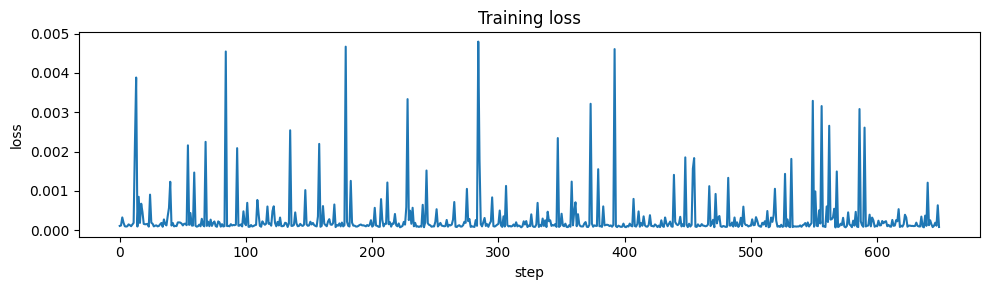

Сохранил: best_model_continued_3epochs.pth


In [87]:
EXTRA_EPOCHS = 5
CONTINUE_LR = 2e-6       # можно 1e-4 / 2e-4 / 5e-5; я бы начал с 2e-4
BEST_MODEL_PATH = "/kaggle/working/best_model_continued_12epochs.pth"

# 1. Загружаем лучшую модель
model = MultiTaskNER(MODEL_NAME, num_ner_labels).to(DEVICE)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))

def freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=3):
    if freeze_embeddings:
        for p in model.encoder.embeddings.parameters():
            p.requires_grad = False

    for i, layer in enumerate(model.encoder.transformer.layer):
        if i < freeze_n_layers:
            for p in layer.parameters():
                p.requires_grad = False

# если нужно, снова замораживаем так же, как раньше
freeze_encoder_layers(model, freeze_embeddings=True, freeze_n_layers=2)

# 2. Новый optimizer для дообучения
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONTINUE_LR,
    weight_decay=0.05
)

# 3. Новый scheduler только на 3 эпохи
total_steps = len(dataloader) * EXTRA_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

# 4. Дообучение
model.train()
continue_loss_history = []

for epoch in range(EXTRA_EPOCHS):
    total_loss = 0.0

    for step, batch in enumerate(dataloader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        continue_loss_history.append(loss.item())
        total_loss += loss.item()

        if (step + 1) % 50 == 0:
            plot_loss(continue_loss_history)
            print(
                f"[CONTINUE] Epoch {epoch+1}/{EXTRA_EPOCHS} | "
                f"step {step+1}/{len(dataloader)} | "
                f"loss {loss.item():.4f}"
            )

    avg_loss = total_loss / len(dataloader)
    print(f"[CONTINUE] Epoch {epoch+1}/{EXTRA_EPOCHS} avg loss: {avg_loss:.4f}")

# 5. График
plot_loss(continue_loss_history)

# 6. Сохраняем дообученную модель
torch.save(model.state_dict(), "best_model_continued_18epochs.pth")
print("Сохранил: best_model_continued_3epochs.pth")

In [89]:
# relearn_path = 'best_model_continued_12epochs.pth'

In [90]:
model.eval()


def decode_triplets(pred_ids, offsets, attention_mask):
    triplets = []
    current_start = None
    current_end = None
    current_label = None

    def flush_current():
        nonlocal current_start, current_end, current_label
        if current_label is not None:
            triplets.append((current_start, current_end, current_label))
            current_start = None
            current_end = None
            current_label = None

    for pred_id, (tok_start, tok_end), mask in zip(pred_ids, offsets, attention_mask):
        if mask == 0 or tok_start == tok_end:
            continue

        tag = bio_labels[int(pred_id)]
        if tag == "O":
            flush_current()
            continue

        prefix, label = tag.split("-", 1)

        if prefix == "B":
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        if current_label != label:
            flush_current()
            current_start = int(tok_start)
            current_end = int(tok_end)
            current_label = label
            continue

        current_end = int(tok_end)

    flush_current()
    return triplets


@torch.no_grad()
def predict_triplets(texts, batch_size=64):
    all_triplets = []

    for start_idx in range(0, len(texts), batch_size):
        batch_texts = texts[start_idx:start_idx + batch_size]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
            return_offsets_mapping=True,
        )

        offset_mapping = encoded.pop("offset_mapping")
        attention_mask = encoded["attention_mask"]
        batch = {k: v.to(DEVICE) for k, v in encoded.items()}

        outputs = model(**batch)
        ner_pred_ids = outputs["ner_logits"].argmax(dim=-1).cpu()
        cls_pred_ids = outputs["cls_logits"].argmax(dim=-1).cpu()

        for has_entity, pred_ids, offsets, mask in zip(
            cls_pred_ids.tolist(),
            ner_pred_ids.tolist(),
            offset_mapping.tolist(),
            attention_mask.tolist(),
        ):
            if has_entity == 0:
                all_triplets.append([])
                continue

            all_triplets.append(decode_triplets(pred_ids, offsets, mask))

    return all_triplets


pred_triplets = predict_triplets(df["text"].to_list())

# offset_mapping уже даёт символьные индексы токенов в исходной строке,
# поэтому для ответа берём первый start и последний end у непрерывного BIO-спана.
def format_prediction(triplets):
    if not triplets:
        return '[]'
    parts = [f"({int(s)}, {int(e)}, '{l}')" for s, e, l in triplets]
    return f'[{", ".join(parts)}]'


formatted_predictions = [format_prediction(triplets) for triplets in pred_triplets]

submission_df = df.select("id", "text").with_columns(
    pl.Series("Prediction", formatted_predictions, dtype=pl.Utf8)
)

submission_df.drop("text").write_csv("predictions.csv")
submission_df.head(10)

id,text,Prediction
i64,str,str
0,"""Банкомат не запрашивает CVV-ко…","""[]"""
1,"""Уточните, пожалуйста, ФИО полу…","""[(106, 124, 'Номер телефона')]"""
2,"""Проверьте папку «Спам» в вашей…","""[]"""
3,"""Я пытаюсь обновить данные в ли…","""[(88, 93, 'Паспортные данные')…"
4,"""Хочу подключить СМС-информиров…","""[(82, 94, 'Водительское удосто…"
5,"""Могу ли я закрыть счет по врем…","""[(51, 63, 'Временное удостовер…"
6,"""Проверьте, пожалуйста, нет ли …","""[]"""
7,"""Мой СНИЛС 300-400-500 05 не пр…","""[(10, 24, 'СНИЛС клиента')]"""
8,"""Я пытался расплатиться картой …","""[(57, 61, 'ПИН код')]"""


In [86]:
model

MultiTaskNER(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linea